<a href="https://colab.research.google.com/github/Surhan-Memon/Gene-Expression-using-knn/blob/main/Gene_Expression_using_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/gene_knn_dataset (1).csv')

In [3]:
df.head()

,Gene_One_Expression,Gene_Two_Expression,Cancer_Present
0,6.29,6.75,1
1,9.72,6.72,1
2,2.89,5.22,0
3,6.14,5.38,1
4,2.17,4.60,0


<Axes: xlabel='Gene_One_Expression', ylabel='Gene_Two_Expression'>

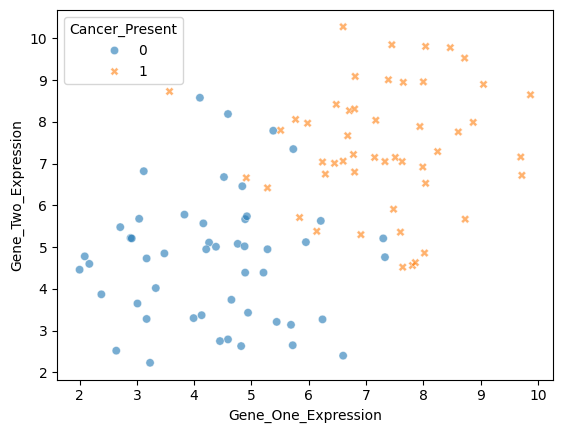

In [4]:
sns.scatterplot(data=df,x='Gene_One_Expression', y='Gene_Two_Expression', hue='Cancer_Present', alpha=0.6, style='Cancer_Present')

In [5]:
len(df)

100

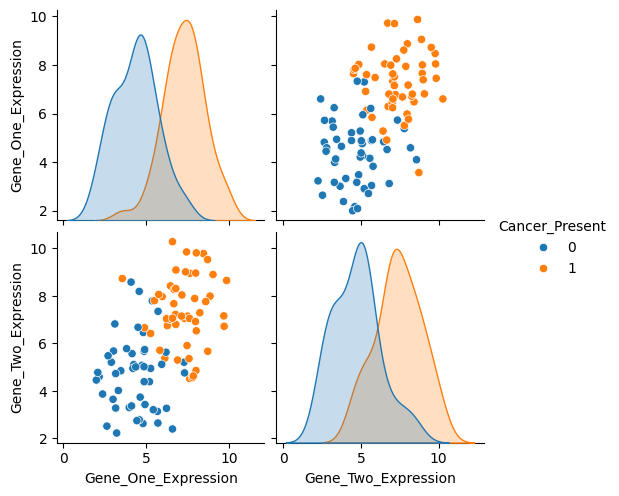

In [6]:
sns.pairplot(data=df, hue='Cancer_Present')

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
X = df.drop('Cancer_Present', axis=1)
y = df['Cancer_Present']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
scaler = StandardScaler()

In [12]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [13]:
from sklearn.neighbors import KNeighborsClassifier

In [14]:
knn_model = KNeighborsClassifier(n_neighbors=1)

In [15]:
knn_model.fit(scaled_X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [16]:
y_pred = knn_model.predict(scaled_X_test)

In [17]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

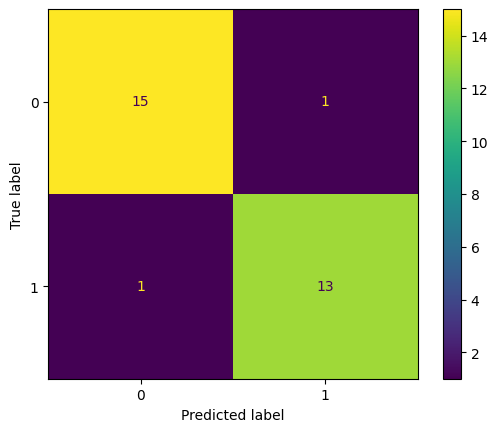

In [18]:
cm = confusion_matrix(y_test, y_pred)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [19]:
len(y_test)

30

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        16
           1       0.93      0.93      0.93        14

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [21]:
df['Cancer_Present'].value_counts()

,count
Cancer_Present,
1,50
0,50


In [22]:
from sklearn.metrics import accuracy_score

1 - accuracy_score(y_test,y_pred)

0.06666666666666665

In [23]:
test_error_rates = []

for k in range(1,30):
  knn_model = KNeighborsClassifier(n_neighbors=k)
  knn_model.fit(scaled_X_train, y_train)
  y_pred_test = knn_model.predict(scaled_X_test)
  test_error = 1 - accuracy_score(y_test, y_pred_test)
  test_error_rates.append(test_error)

In [24]:
test_error_rates

[0.06666666666666665,
 0.09999999999999998,
 0.1333333333333333,
 0.09999999999999998,
 0.09999999999999998,
 0.09999999999999998,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665,
 0.06666666666666665]

Text(0.5, 0, 'K Neighbors')

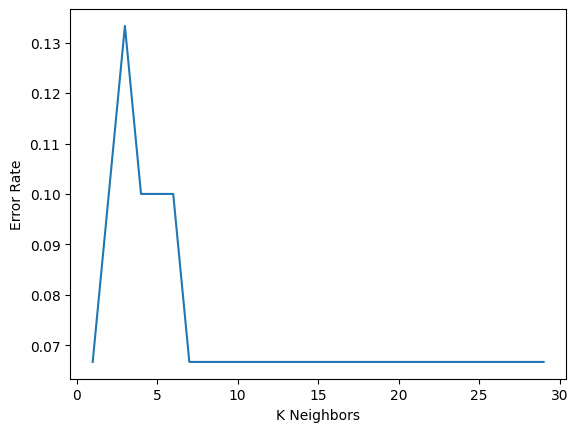

In [25]:
plt.plot(range(1,30), test_error_rates)
plt.ylabel('Error Rate')
plt.xlabel('K Neighbors')

In [26]:
scaler = StandardScaler()

In [27]:
knn = KNeighborsClassifier()

In [28]:
knn.get_params().keys()

dict_keys(['algorithm', 'leaf_size', 'metric', 'metric_params', 'n_jobs', 'n_neighbors', 'p', 'weights'])

In [29]:
operations  = [('scaler', scaler), ('knn', knn)]

In [30]:
from sklearn.pipeline import Pipeline

In [31]:
pipe = Pipeline(operations)

In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
k_values = list(range(1,20))

In [34]:
k_values

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

In [38]:
param_grid = {'knn__n_neighbors': k_values}

In [39]:
full_cv_classifier = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')

In [40]:
full_cv_classifier.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19]},
             scoring='accuracy')

In [41]:
full_cv_classifier.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier(n_neighbors=6))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=6),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 6,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [43]:
full_predictions = full_cv_classifier.predict(X_test)

In [46]:
print(classification_report(y_test, full_predictions))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90        16
           1       0.87      0.93      0.90        14

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [47]:
new_patient = [[3.8, 6.4]]

In [48]:
full_cv_classifier.predict(new_patient)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

In [49]:
full_cv_classifier.predict_proba(new_patient)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.83333333, 0.16666667]])